# Regularization
**Regularization** is a technique that adds a penalty term to a model's loss function to prevent overfitting and improve generalization. It deliberately increases training error (bias) slightly to reduce testing error (variance).

## Linear Model Overfitting
Linear models tend to overfit when the number of samples is small, especially when the number of features is large.

In [24]:
import pandas as pd

housing = pd.read_csv("../ames.csv")
features = [
    "Lot Frontage",
    "Lot Area",
    "Pool Area",
    "Year Built",
    "Yr Sold"
]
target_name = "SalePrice"
cleaned = housing[features + [target_name]].dropna()
data = cleaned[features]
target = cleaned[target_name]

In [25]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

linear_regression = make_pipeline(
    PolynomialFeatures(
        degree=2,
        include_bias=False
    ),
    LinearRegression()
).set_output(transform="pandas")

cv_results = cross_validate(
    linear_regression,
    data,
    target,
    cv=10,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
)

In [26]:
train_error = -cv_results["train_score"]
print(
    "Mean squared error of linear regression model on the train set:\n"
    f"{train_error.mean():.2e} ± {train_error.std():.2e}"
)

Mean squared error of linear regression model on the train set:
2.93e+09 ± 1.59e+08


In [27]:
test_error = -cv_results["test_score"]
print(
    "Mean squared error of linear regression model on the test set:\n"
    f"{test_error.mean():.2e} ± {test_error.std():.2e}"
)

Mean squared error of linear regression model on the test set:
6.45e+09 ± 6.96e+09


When we see such a significant different in the training error and testing error (where the training error is much lower), it is a sign of overfitting. Part of this is the use of a polynomial feature transformer, for instance, `Pool Area * Yr Sold` is not likely to be very predictive.

We can analyze the weights of the model.

In [28]:
model_first_fold = cv_results["estimator"][0]
model_first_fold

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [29]:
feature_names = model_first_fold[-1].feature_names_in_
feature_names

array(['Lot Frontage', 'Lot Area', 'Pool Area', 'Year Built', 'Yr Sold',
       'Lot Frontage^2', 'Lot Frontage Lot Area',
       'Lot Frontage Pool Area', 'Lot Frontage Year Built',
       'Lot Frontage Yr Sold', 'Lot Area^2', 'Lot Area Pool Area',
       'Lot Area Year Built', 'Lot Area Yr Sold', 'Pool Area^2',
       'Pool Area Year Built', 'Pool Area Yr Sold', 'Year Built^2',
       'Year Built Yr Sold', 'Yr Sold^2'], dtype=object)

In [30]:
coefs = [est[-1].coef_ for est in cv_results["estimator"]]
weights_linear_regression = pd.DataFrame(coefs, columns=feature_names)

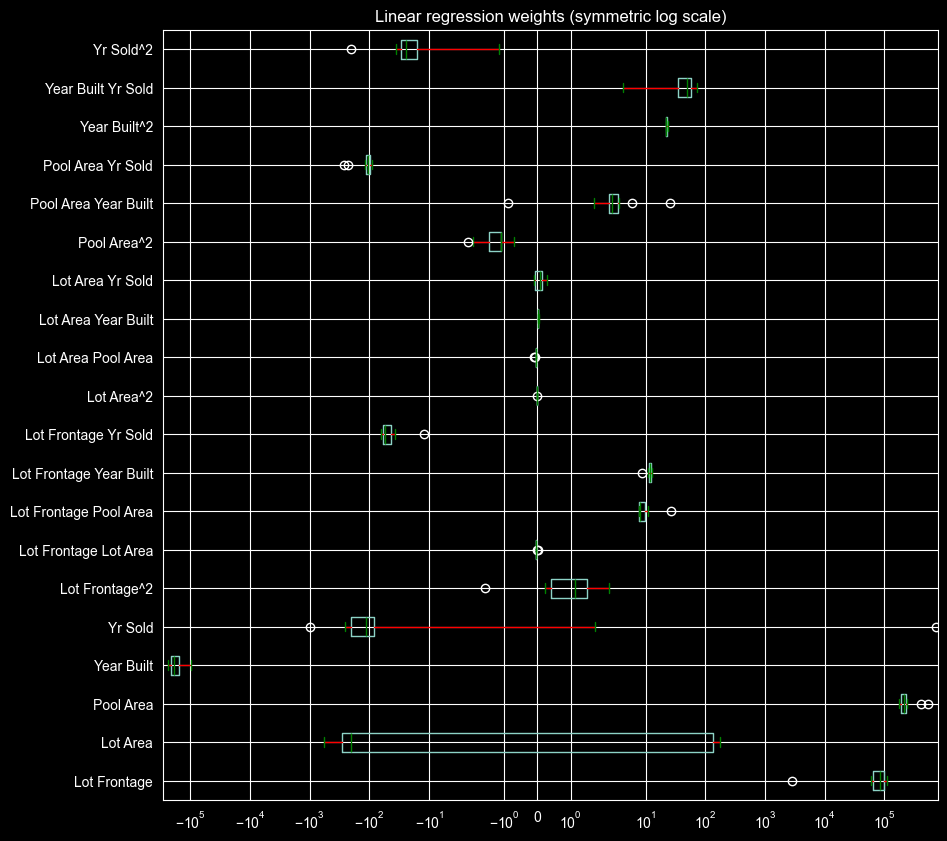

In [31]:
import matplotlib.pyplot as plt

color = {"whiskers": "red", "medians": "green", "caps": "green"}
fig, ax = plt.subplots(figsize=(10, 10))
weights_linear_regression.plot.box(color=color, vert=False, ax=ax)
_ = ax.set(
    title="Linear regression weights (symmetric log scale)",
    xscale="symlog",
)

Without regularization (in this example), we see the *bias-variance tradeoff* introduced by using regularization (like the `Ridge` regression).
- Without regularization, there tends to be *high variance* and *low to no bias*. This is exemplified by the coefficients unstable across cross-validation folds and ranging from being very large to very small.
- With regularization, there is *lower variance* but an enforced *higher bias*. As we will see, the coefficients will tend to be more stable across folds and closer in magnitude.

## Introducing Regularization
One method to introduce regularization is the `Ridge` regression. This is a linear regression model with the addition of the `alpha` parameter, which can range from zero to infinity.

`Ridge` tries to pull the coefficients towards zero. The higher the value of `alpha`, the stronger the regularization. When `alpha` is zero, it is effectively the same as a normal linear regression without regularization.

In [21]:
from sklearn.linear_model import Ridge

ridge = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=100, solver="cholesky"),
)

cv_results = cross_validate(
    ridge,
    data,
    target,
    cv=20,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
)

/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.377762096178829e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.363203548482254e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.364199433363894e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcon

The above code will generate warnings (depending on the solver used).

In [22]:
train_error = -cv_results["train_score"]
print(
    "Mean squared error of ridge model on the train set:\n"
    f"{train_error.mean():.2e} ± {train_error.std():.2e}"
)

Mean squared error of ridge model on the train set:
2.96e+09 ± 9.57e+07


In [23]:
test_error = -cv_results["test_score"]
print(
    "Mean squared error of ridge model on the test set:\n"
    f"{test_error.mean():.2e} ± {test_error.std():.2e}"
)

Mean squared error of ridge model on the test set:
4.86e+09 ± 6.48e+09


Compared to our initial linear model, without the `Ridge` regularization, the gap in train and test scores is closing but is still indicating overfitting.


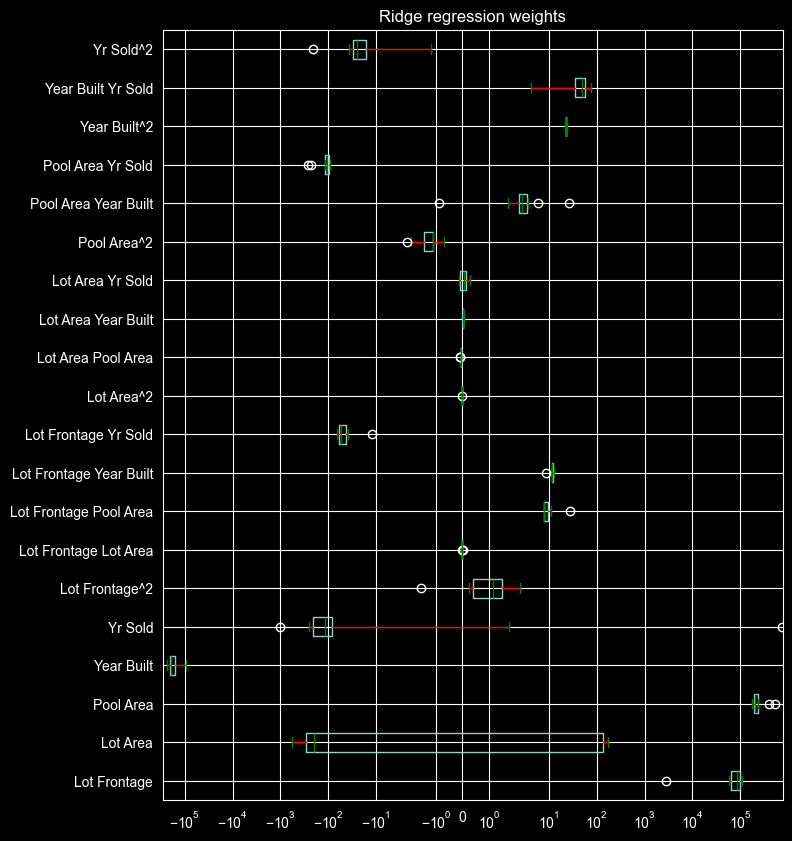

In [34]:
coefs = [est[-1].coef_ for est in cv_results["estimator"]]
weights_ridge = pd.DataFrame(coefs, columns=feature_names)

fig, ax = plt.subplots(figsize=(8, 10))
weights_ridge.plot.box(color=color, vert=False, ax=ax)
_ = ax.set(
    title="Ridge regression weights",
    xscale="symlog",
)

Desite the values of the weights being less extreme, they are still unstable from fold-to-fold. This can also change drastically depending on the solver used.

## Feature Scaling and Regularization
When features exist in similar scales and units, if they are found to be equally important by the model, they are affected similarly by the regularization strength. When features have completely different data scales (i.e., age in years and revenue in millions of dollars), and again the model determines them equally predictive, fitting a linear regression without scaling and without regularization would give a higher weight to the feature with the *smallest natural scale*.

The `MinMaxScaler` scales each feature individually such that its range maps between zero and one.

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaled_ridge = make_pipeline(
    MinMaxScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=10, solver="cholesky"),
)

cv_results = cross_validate(
    scaled_ridge,
    data,
    target,
    cv=10,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
)

In [36]:
train_error = -cv_results["train_score"]
print(
    "Mean squared error of scaled ridge model on the train set:\n"
    f"{train_error.mean():.2e} ± {train_error.std():.2e}"
)

Mean squared error of scaled ridge model on the train set:
3.69e+09 ± 1.98e+08


In [37]:
test_error = -cv_results["test_score"]
print(
    "Mean squared error of scaled ridge model on the test set:\n"
    f"{test_error.mean():.2e} ± {test_error.std():.2e}"
)

Mean squared error of scaled ridge model on the test set:
3.93e+09 ± 1.82e+09


This scaling has a positive impact on the test error, meaning our model is less overfitted.

In [38]:
coefs = [est[-1].coef_ for est in cv_results["estimator"]]
weights_ridge_scaled_data = pd.DataFrame(coefs, columns=feature_names)

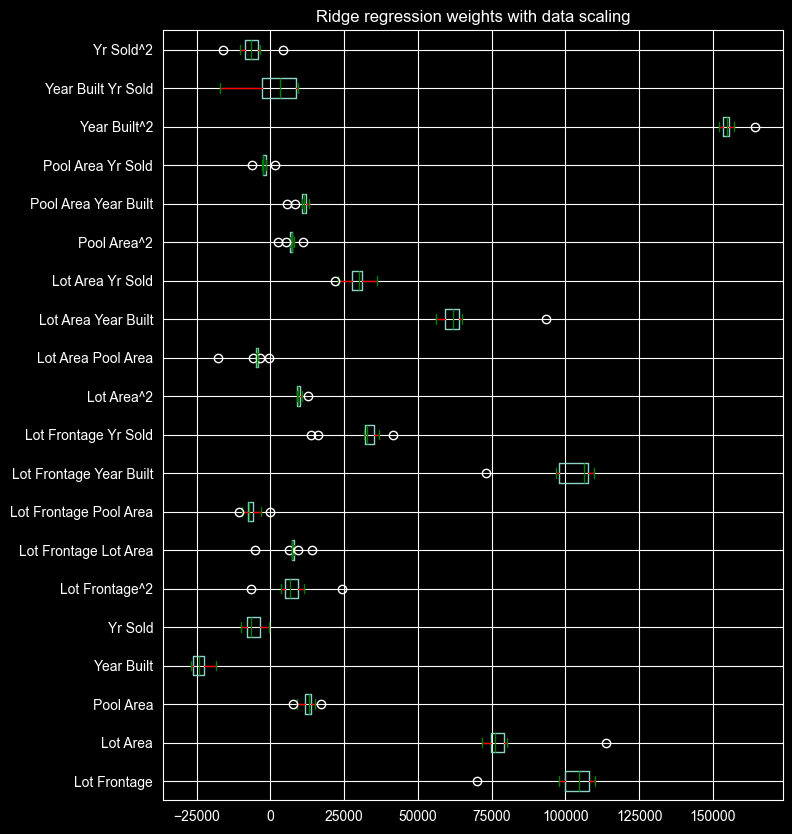

In [40]:
fig, ax = plt.subplots(figsize=(8, 10))
weights_ridge_scaled_data.plot.box(color=color, vert=False, ax=ax)
_ = ax.set(title="Ridge regression weights with data scaling")

Most weight magnitudes have a similar order of magnitude, and the number of unstable weights decreased. The larger `alpha` becomes, the more the weights decrease.

## Tuning the Regularization Parameter
We need to ensure that we tune the hyperparameter `alpha` within the cross-validation. Thus, we could use something like a `GridSearchCV`, however, in this case the `RidgeCV` regressor exists.

In [41]:
import numpy as np
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-7, 5, num=100)
ridge = make_pipeline(
    MinMaxScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    RidgeCV(alphas=alphas, store_cv_results=True)
)

In [42]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=50, random_state=0)
cv_results = cross_validate(
    ridge,
    data,
    target,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
    n_jobs=2,
)

In [43]:
train_error = -cv_results["train_score"]
print(
    "Mean squared error of tuned ridge model on the train set:\n"
    f"{train_error.mean():.2e} ± {train_error.std():.2e}"
)

Mean squared error of tuned ridge model on the train set:
3.08e+09 ± 1.10e+08


In [44]:
test_error = -cv_results["test_score"]
print(
    "Mean squared error of tuned ridge model on the test set:\n"
    f"{test_error.mean():.2e} ± {test_error.std():.2e}"
)

Mean squared error of tuned ridge model on the test set:
4.02e+09 ± 2.51e+09


We can now visualize the `alphas` that the model used to find the optimal `alpha` range for the model.

In [46]:
mse_alphas = [
    est[-1].cv_results_.mean(axis=0) for est in cv_results["estimator"]
]
cv_alphas = pd.DataFrame(mse_alphas, columns=alphas)
cv_alphas = cv_alphas.aggregate(["mean", "std"]).T
cv_alphas

,mean,std
1.000000e-07,5.048592e+09,9.920624e+08
1.321941e-07,5.048513e+09,9.919146e+08
1.747528e-07,5.048410e+09,9.917194e+08
2.310130e-07,5.048273e+09,9.914618e+08
3.053856e-07,5.048092e+09,9.911220e+08
...,...,...
3.274549e+04,6.929849e+09,1.348974e+08
4.328761e+04,6.942544e+09,1.351486e+08
5.722368e+04,6.952210e+09,1.353403e+08
7.564633e+04,6.959559e+09,1.354864e+08


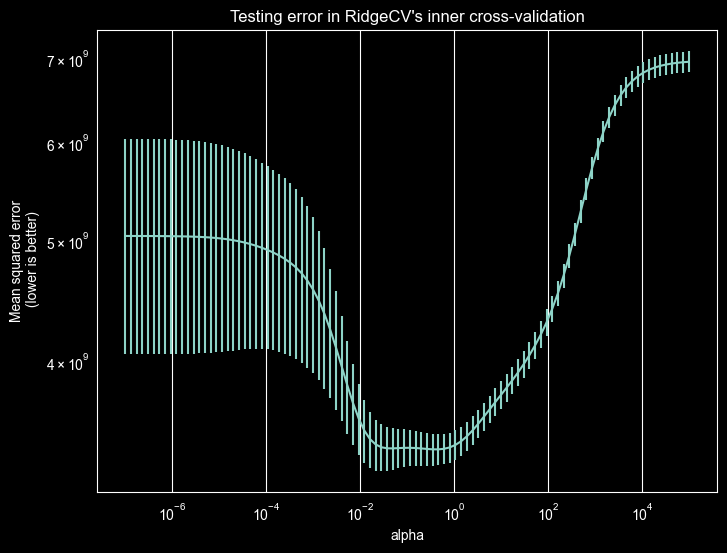

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(cv_alphas.index, cv_alphas["mean"], yerr=cv_alphas["std"])
_ = ax.set(
    xscale="log",
    xlabel="alpha",
    yscale="log",
    ylabel="Mean squared error\n (lower is better)",
    title="Testing error in RidgeCV's inner cross-validation",
)

In [48]:
best_alphas = [est[-1].alpha_ for est in cv_results["estimator"]]
best_alphas

[0.2009233002565046,
 0.4641588833612782,
 0.037649358067924715,
 0.028480358684358047,
 0.6135907273413176,
 0.037649358067924715,
 0.6135907273413176,
 0.4641588833612782,
 0.021544346900318867,
 0.037649358067924715,
 0.012328467394420659,
 0.35111917342151344,
 0.2009233002565046,
 0.037649358067924715,
 0.037649358067924715,
 0.037649358067924715,
 0.6135907273413176,
 0.4641588833612782,
 0.04977023564332114,
 0.2009233002565046,
 0.037649358067924715,
 0.016297508346206434,
 0.012328467394420659,
 0.4641588833612782,
 0.037649358067924715,
 0.26560877829466895,
 0.6135907273413176,
 0.037649358067924715,
 0.037649358067924715,
 0.037649358067924715,
 0.4641588833612782,
 0.06579332246575682,
 0.6135907273413176,
 0.4641588833612782,
 0.021544346900318867,
 0.4641588833612782,
 0.037649358067924715,
 0.4641588833612782,
 0.2009233002565046,
 0.4641588833612782,
 0.06579332246575682,
 0.037649358067924715,
 0.04977023564332114,
 0.4641588833612782,
 0.4641588833612782,
 0.46415888

In [49]:
print(
    f"Min optimal alpha: {np.min(best_alphas):.2f} and "
    f"Max optimal alpha: {np.max(best_alphas):.2f}"
)

Min optimal alpha: 0.01 and Max optimal alpha: 0.61


Important Notes:
- Scaling features makes the effect of regularization more even. All variables are regularized by comparable magnitude, which would not necessarily be the case with the natural feature scales.
- Scaling features makes the numerical solvers more stable which is also helpful to tune the regularization parameter more independently of the solver.

## Regularization for Logistic Regression
By default, `LogisticRegression(C=1)` is regularized through the `C` parameter. It is the inverse of `alpha`, such that if `C` is large, there is weaker regularization.

The stronger the regularization, the region of the feature space where the model is not confident will be *larger*.

This is the opposite with weaker regularization, but also, we can see the orientation of the decision lines change as the data points closer to the decision boundary have a greater impact. This is clearly seen on the left where the data points farther from the decision boundary pull the orientation towards the larger clusters. On the right, we can see that the data points in the middle nearly match the orientation of the line.

![logisticreg](logisticreg.png)